In [1]:
pwd

'/grid/klindt/home/issa/0_Superposition-Paper/MachInterp'

# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import mis

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

import data
from data import loadData

import similarities
from similarities import loadMetrics

# Get data

In [3]:
identifier='Vinken2023'
region='IT'
images, activations=loadData(identifier,region)
images.shape, activations.shape

(torch.Size([1379, 3, 224, 224]), torch.Size([1379, 449]))

# Get metrics and precompute similarities

In [4]:
sim_metrics = ['dreamsim','lpips']
all_metrics=loadMetrics(sim_metrics=sim_metrics, identifier=identifier, region=region, images=images)
dreamsim = all_metrics['dreamsim']
lpips = all_metrics['lpips']

dreamsim embeddings not found, precomputing now...
Using cached ./models


Using cache found in ./models/facebookresearch_dino_main
/grid/klindt/home/issa/miniconda3/envs/mis_venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Embedding images.


100%|██████████| 6/6 [01:06<00:00, 11.14s/it]


Computing similarities.
Dreamsim: Precomputed embeddings and similarities. Now, use precomputed_similarity with indices!
You can also save metric.similarity_matrix and use it to initialize PrecomputedMetric
this is to avoid precomputing next time.
Embeddings for dreamsim saved to shared folder.
(1379, 1379)
lpips embeddings found in shared folder
(1379, 1379, 6)


# Compute MIS

In [5]:
quantiles = np.linspace(0, 0.5, 10)
result = mis.compute_score(
    inputs=images,
    activations=activations.numpy(),
    metrics={
        'dreamsim': dreamsim, 
        'lpips': lpips
    },
    quantiles=quantiles,
    num_trials=50
)

100%|██████████| 449/449 [01:29<00:00,  5.01it/s]


# Analyze results

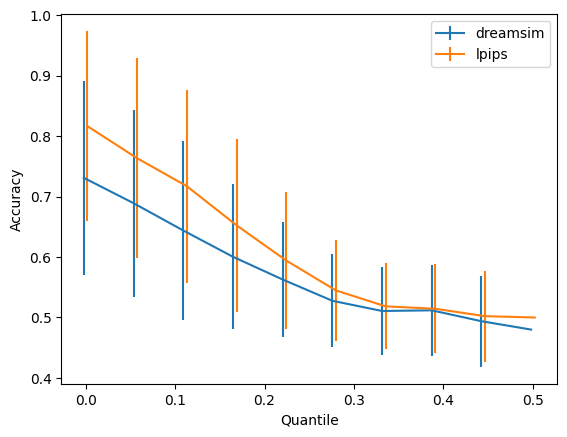

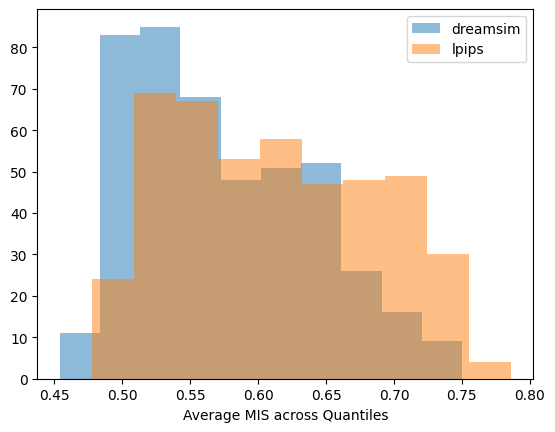

In [6]:
# show results
plt.errorbar(
    quantiles - .002, 
    result['accuracy_dreamsim'].mean(0), 
    result['accuracy_dreamsim'].std(0),
    label='dreamsim'
)
plt.errorbar(
    quantiles + .002, 
    result['accuracy_lpips'].mean(0), 
    result['accuracy_lpips'].std(0),
    label='lpips'
)
plt.xlabel('Quantile')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.hist(result['accuracy_dreamsim'].mean(1), alpha=.5, label='dreamsim')
plt.hist(result['accuracy_lpips'].mean(1), alpha=.5, label='lpips')
plt.xlabel('Average MIS across Quantiles')
plt.legend()
plt.show()

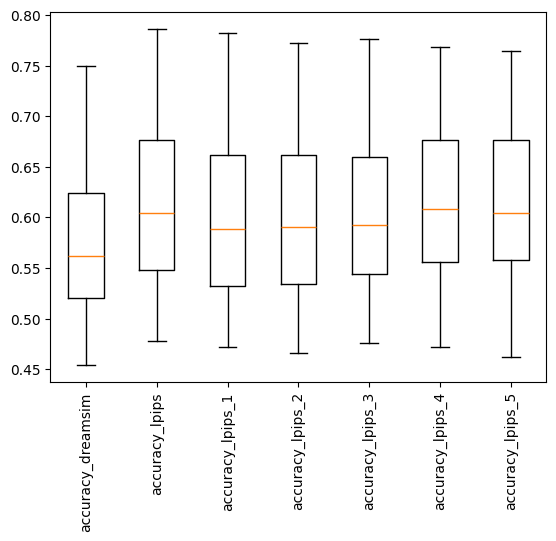

In [7]:
stats, labels = [], []
for key in result:
    if 'accuracy' in key:
        stats.append(result[key].mean(1))
        labels.append(key)

plt.boxplot(stats)
plt.xticks(np.arange(len(stats)) + 1, labels, rotation=90)
plt.show()